In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/1776311302-P3-Car Market Trends Analysis with Car Dekho Data.csv')

In [ ]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
df.shape

(301, 9)

In [ ]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(299, 9)

In [ ]:
df['Year'].min(), df['Year'].max()

(2003, 2018)

In [ ]:
df['Selling_Price'].min(), df['Selling_Price'].max()

(0.1, 35.0)

In [ ]:
df['Selling_Price'].mean()

np.float64(4.589632107023411)

In [ ]:
df['Selling_Price'].median()

3.51

In [ ]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
df['Car_Name'].nunique()

98

In [ ]:
df['Car_Name'].value_counts().head()

,count
Car_Name,
city,26
corolla altis,16
verna,14
brio,10
fortuner,10


In [ ]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,58
CNG,2


In [ ]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,193
Individual,106


In [ ]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,193
Individual,106


In [ ]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,260
Automatic,39


In [ ]:
df['Owner'].value_counts()

,count
Owner,
0,288
1,10
3,1


In [ ]:
df['Depreciation'] = df['Present_Price'] - df['Selling_Price']

In [ ]:
df.loc[df['Depreciation'].idxmax(), ['Car_Name', 'Present_Price', 'Selling_Price', 'Depreciation']]

,86
Car_Name,land cruiser
Present_Price,92.6
Selling_Price,35.0
Depreciation,57.6


In [ ]:
df.loc[df['Depreciation'].idxmin(), ['Car_Name', 'Present_Price', 'Selling_Price', 'Depreciation']]

,155
Car_Name,Honda Activa 4G
Present_Price,0.51
Selling_Price,0.48
Depreciation,0.03


In [ ]:
df.groupby('Car_Name')['Depreciation'].mean().sort_values().head(10).rename_axis('Vehicle_Name')

,Depreciation
Vehicle_Name,
TVS Sport,0.040
Honda Activa 4G,0.045
Hero Passion X pro,0.050
Bajaj Avenger 150,0.050
Honda Dream Yuga,0.060
Yamaha FZ 16,0.070
Activa 4g,0.110
Hero Splender iSmart,0.115
Royal Enfield Bullet 350,0.120


In [ ]:
df[['Year', 'Kms_Driven', 'Present_Price', 'Selling_Price', 'Depreciation']].corr()

,Year,Kms_Driven,Present_Price,Selling_Price,Depreciation
Year,1.000000,-0.525714,-0.053563,0.234369,-0.336349
Kms_Driven,-0.525714,1.000000,0.205253,0.028566,0.334104
Present_Price,-0.053563,0.205253,1.000000,0.876378,0.868186
Selling_Price,0.234369,0.028566,0.876378,1.000000,0.521860
Depreciation,-0.336349,0.334104,0.868186,0.521860,1.000000


In [ ]:
df[df['Year'] > 2014]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2.60
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0,0.58
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0,1.37
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0,2.11
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0,0.14
...,...,...,...,...,...,...,...,...,...,...
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0,4.54
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,2.10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,1.90
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,1.00


In [ ]:
two_wheeler_data = df[
    df['Car_Name'].str.contains(
        'Royal Enfield|KTM|Bajaj|Hyosung|Mojo|Yamaha|TVS|Hero|Activa|Honda CB|Honda CBR|Honda Dream|Honda Karizma|UM|Suzuki Access',
        case=False,
        na=False
    )
]

two_wheeler_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation
100,Royal Enfield Thunder 500,2016,1.75,1.90,3000,Petrol,Individual,Manual,0,0.15
101,UM Renegade Mojave,2017,1.70,1.82,1400,Petrol,Individual,Manual,0,0.12
102,KTM RC200,2017,1.65,1.78,4000,Petrol,Individual,Manual,0,0.13
103,Bajaj Dominar 400,2017,1.45,1.60,1200,Petrol,Individual,Manual,0,0.15
104,Royal Enfield Classic 350,2017,1.35,1.47,4100,Petrol,Individual,Manual,0,0.12
...,...,...,...,...,...,...,...,...,...,...
196,Activa 3g,2008,0.17,0.52,500000,Petrol,Individual,Automatic,0,0.35
197,Honda CB twister,2010,0.16,0.51,33000,Petrol,Individual,Manual,0,0.35
198,Bajaj Discover 125,2011,0.15,0.57,35000,Petrol,Individual,Manual,1,0.42
199,Honda CB Shine,2007,0.12,0.58,53000,Petrol,Individual,Manual,0,0.46


In [ ]:
two_wheeler_data.loc[two_wheeler_data['Year'].idxmin()]

,189
Car_Name,Hero Super Splendor
Year,2005
Selling_Price,0.2
Present_Price,0.57
Kms_Driven,55000
Fuel_Type,Petrol
Seller_Type,Individual
Transmission,Manual
Owner,0
Depreciation,0.37


In [ ]:
two_wheeler_data.loc[two_wheeler_data['Year'].idxmax()]

,101
Car_Name,UM Renegade Mojave
Year,2017
Selling_Price,1.7
Present_Price,1.82
Kms_Driven,1400
Fuel_Type,Petrol
Seller_Type,Individual
Transmission,Manual
Owner,0
Depreciation,0.12


In [ ]:
two_wheeler_data['Car_Name'].value_counts().head()

,count
Car_Name,
Royal Enfield Classic 350,7
Royal Enfield Thunder 350,4
Bajaj Pulsar 150,4
Bajaj Avenger 220,3
Royal Enfield Thunder 500,3


In [ ]:
two_wheeler_data[two_wheeler_data['Selling_Price'] > two_wheeler_data['Present_Price']]

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation


In [ ]:
two_wheeler_data.sort_values('Depreciation').head(10)[
    ['Car_Name', 'Year', 'Present_Price', 'Selling_Price', 'Kms_Driven', 'Depreciation']
]

,Car_Name,Year,Present_Price,Selling_Price,Kms_Driven,Depreciation
155,Honda Activa 4G,2017,0.51,0.48,4300,0.03
156,TVS Sport,2017,0.52,0.48,15000,0.04
126,Bajaj Avenger 220,2017,0.95,0.90,1300,0.05
127,Bajaj Avenger 150,2016,0.80,0.75,7000,0.05
151,Hero Passion X pro,2016,0.55,0.50,31000,0.05
129,Yamaha FZ S V 2.0,2017,0.84,0.78,5000,0.06
159,Honda Activa 4G,2017,0.51,0.45,4000,0.06
158,Honda Dream Yuga,2017,0.54,0.48,8600,0.06
131,Yamaha FZ 16,2015,0.82,0.75,18000,0.07
128,Honda CB Hornet 160R,2017,0.87,0.80,3000,0.07


In [ ]:
car_data = df[~df.index.isin(two_wheeler_data.index)]
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Depreciation
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,2.24
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,4.79
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,2.60
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,1.30
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,2.27
...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0,2.10
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0,1.90
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0,7.65
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0,1.00


In [ ]:
car_data.loc[car_data['Year'].idxmin()]

,37
Car_Name,800
Year,2003
Selling_Price,0.35
Present_Price,2.28
Kms_Driven,127000
Fuel_Type,Petrol
Seller_Type,Individual
Transmission,Manual
Owner,0
Depreciation,1.93


In [ ]:
car_data.loc[car_data['Year'].idxmax()]

,5
Car_Name,vitara brezza
Year,2018
Selling_Price,9.25
Present_Price,9.83
Kms_Driven,2071
Fuel_Type,Diesel
Seller_Type,Dealer
Transmission,Manual
Owner,0
Depreciation,0.58


In [ ]:
car_data.sort_values('Depreciation').head(10)[
    ['Car_Name', 'Year', 'Present_Price', 'Selling_Price', 'Kms_Driven', 'Depreciation']
]

,Car_Name,Year,Present_Price,Selling_Price,Kms_Driven,Depreciation
8,ciaz,2016,8.89,8.75,20273,0.14
231,verna,2017,9.40,9.25,15001,0.15
80,corolla altis,2016,14.89,14.73,23000,0.16
208,i20,2017,8.10,7.90,3435,0.20
234,grand i10,2015,5.70,5.50,4492,0.20
235,verna,2017,9.40,9.10,15141,0.30
214,grand i10,2017,5.70,5.25,20114,0.45
205,grand i10,2016,5.70,5.25,3493,0.45
226,grand i10,2015,5.70,5.25,24678,0.45
261,brio,2016,5.97,5.50,5600,0.47


In [ ]:
car_data.sort_values('Depreciation').head(10)[
    ['Car_Name', 'Year', 'Present_Price', 'Selling_Price', 'Kms_Driven', 'Depreciation']
]

,Car_Name,Year,Present_Price,Selling_Price,Kms_Driven,Depreciation
8,ciaz,2016,8.89,8.75,20273,0.14
231,verna,2017,9.40,9.25,15001,0.15
80,corolla altis,2016,14.89,14.73,23000,0.16
208,i20,2017,8.10,7.90,3435,0.20
234,grand i10,2015,5.70,5.50,4492,0.20
235,verna,2017,9.40,9.10,15141,0.30
214,grand i10,2017,5.70,5.25,20114,0.45
205,grand i10,2016,5.70,5.25,3493,0.45
226,grand i10,2015,5.70,5.25,24678,0.45
261,brio,2016,5.97,5.50,5600,0.47


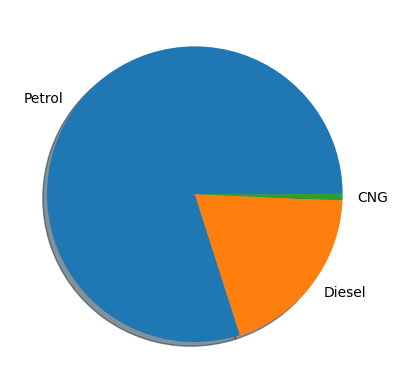

In [ ]:
plt.pie(
    df.Fuel_Type.value_counts(),
    labels=["Petrol", "Diesel", "CNG"],
    shadow=True
)
plt.show()

<Axes: xlabel='Fuel_Type'>

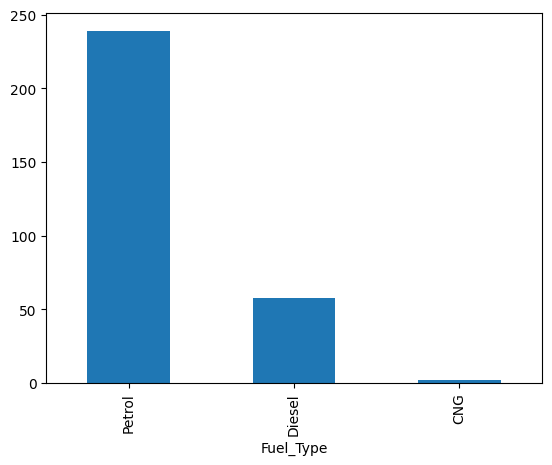

In [ ]:
df.Fuel_Type.value_counts().plot.bar()

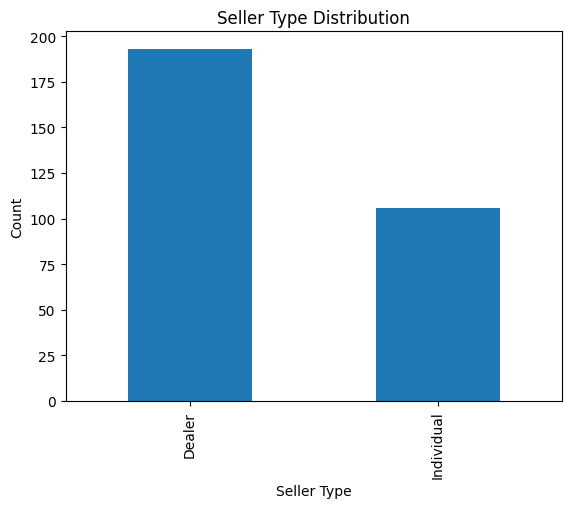

In [ ]:
df.Seller_Type.value_counts().plot.bar()
plt.title('Seller Type Distribution')
plt.xlabel('Seller Type')
plt.ylabel('Count')
plt.show()

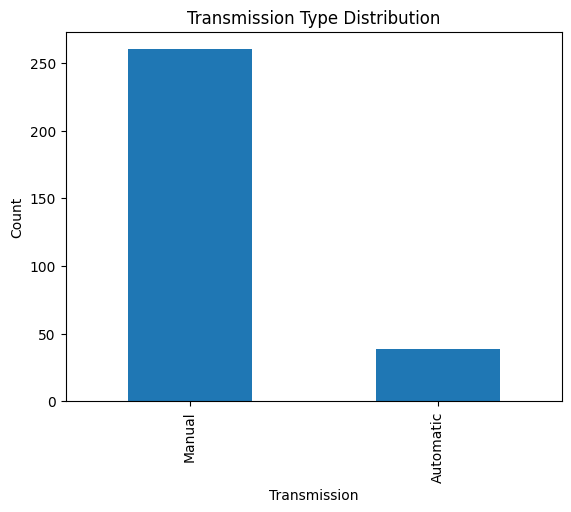

In [ ]:
df.Transmission.value_counts().plot.bar()
plt.title('Transmission Type Distribution')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.show()

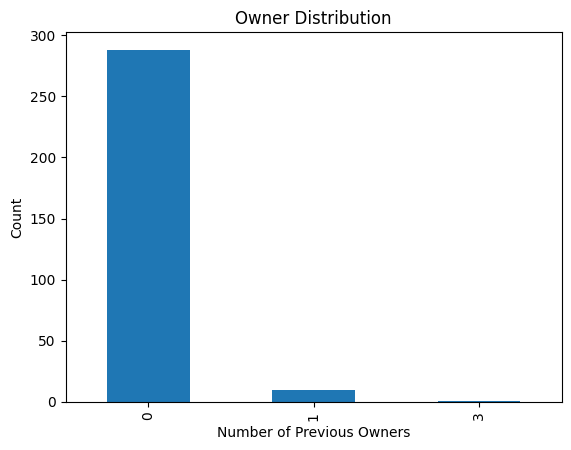

In [ ]:
df.Owner.value_counts().plot.bar()
plt.title('Owner Distribution')
plt.xlabel('Number of Previous Owners')
plt.ylabel('Count')
plt.show()

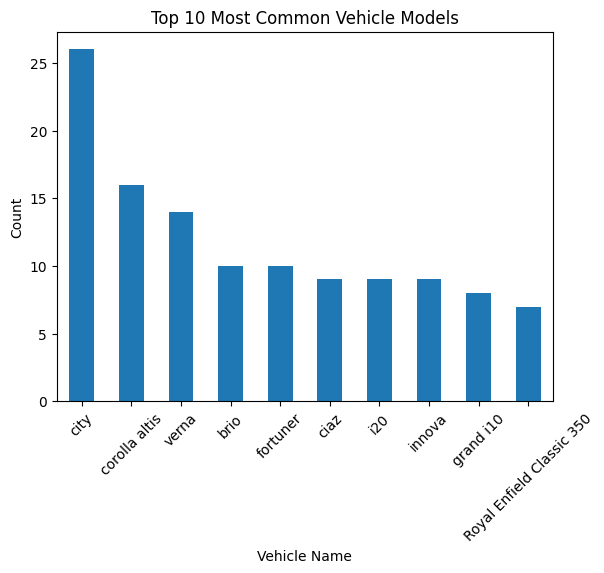

In [ ]:
df.Car_Name.value_counts().head(10).plot.bar()
plt.title('Top 10 Most Common Vehicle Models')
plt.xlabel('Vehicle Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

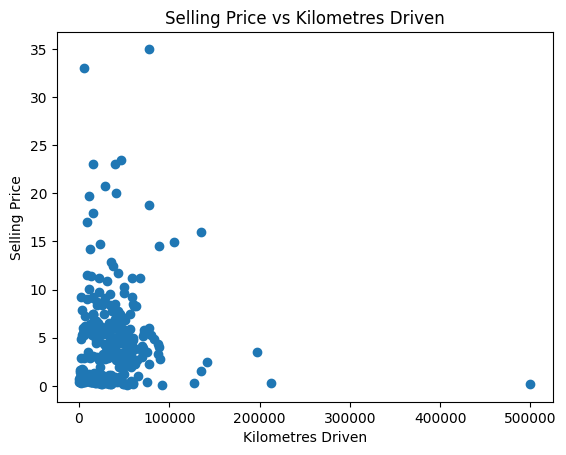

In [ ]:
plt.scatter(df['Kms_Driven'], df['Selling_Price'])
plt.title('Selling Price vs Kilometres Driven')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price')
plt.show()